In [2]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
#Carga desde un archivo .csv sin indice
data= pd.read_csv('Ventas_A_Mensual_Limpia.csv') 

In [4]:
#Verificamos información del DataFrame
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 31 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Vendedor             52 non-null     str    
 1   2024-02-01 00:00:00  52 non-null     str    
 2   2024-03-01 00:00:00  52 non-null     str    
 3   2024-04-01 00:00:00  52 non-null     str    
 4   2024-05-01 00:00:00  52 non-null     str    
 5   2024-06-01 00:00:00  52 non-null     str    
 6   2024-07-01 00:00:00  52 non-null     str    
 7   2024-08-01 00:00:00  52 non-null     str    
 8   2024-09-01 00:00:00  52 non-null     str    
 9   2024-10-01 00:00:00  52 non-null     str    
 10  2024-11-01 00:00:00  52 non-null     str    
 11  2024-12-01 00:00:00  52 non-null     str    
 12  2025-01-01 00:00:00  52 non-null     str    
 13  2025-02-01 00:00:00  52 non-null     str    
 14  2025-03-01 00:00:00  52 non-null     str    
 15  2025-04-01 00:00:00  52 non-null     str    
 16  202

In [5]:
data.head()

,Vendedor,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,...,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00,2026-06-01 00:00:00,2026-07-01 00:00:00
0,PEDRO GONZALEZ ESPINDOLA,,,1,2,,7,2,3,3,...,4.0,3.0,1.0,6.0,2.0,2.0,5.0,2.0,4.0,0.0
1,VICTOR MANUEL SANCHEZ ARRO,,,,,1,1,3,,2,...,7.0,4.0,4.0,5.0,5.0,4.0,2.0,5.0,3.0,2.0
2,MIGUEL ANGEL SONDEREGGER,,,,1,2,7,5,2,2,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,JOSE ANTONIO LICONA MENDE,1,,,2,,,,3,2,...,4.0,3.0,4.0,11.0,4.0,12.0,10.0,6.0,9.0,1.0
4,JAIME GONZALEZ CORONA,,2,3,5,2,3,3,3,4,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [6]:
#Corroboramos valores nulos
valores_nulos=data.isnull().sum()
valores_nulos

Vendedor               0
2024-02-01 00:00:00    0
2024-03-01 00:00:00    0
2024-04-01 00:00:00    0
2024-05-01 00:00:00    0
2024-06-01 00:00:00    0
2024-07-01 00:00:00    0
2024-08-01 00:00:00    0
2024-09-01 00:00:00    0
2024-10-01 00:00:00    0
2024-11-01 00:00:00    0
2024-12-01 00:00:00    0
2025-01-01 00:00:00    0
2025-02-01 00:00:00    0
2025-03-01 00:00:00    0
2025-04-01 00:00:00    0
2025-05-01 00:00:00    0
2025-06-01 00:00:00    0
2025-07-01 00:00:00    0
2025-08-01 00:00:00    0
2025-09-01 00:00:00    0
2025-10-01 00:00:00    0
2025-11-01 00:00:00    0
2025-12-01 00:00:00    0
2026-01-01 00:00:00    0
2026-02-01 00:00:00    0
2026-03-01 00:00:00    0
2026-04-01 00:00:00    0
2026-05-01 00:00:00    0
2026-06-01 00:00:00    0
2026-07-01 00:00:00    0
dtype: int64

División de cuantitativas y cualitativas

In [7]:
#Creo 2 dataframe para poder procesar los outliers, separando las variables cualitativas de las cuantitativas
cualitativas = data['Vendedor']
cuantitativas = data.iloc[:, 1:30]

In [8]:
#Se corroboran los dataframes creados
cualitativas.head()

0      PEDRO GONZALEZ ESPINDOLA
1    VICTOR MANUEL SANCHEZ ARRO
2      MIGUEL ANGEL SONDEREGGER
3     JOSE ANTONIO LICONA MENDE
4         JAIME GONZALEZ CORONA
Name: Vendedor, dtype: str

In [9]:
#Se corroboran los dataframes creados
cuantitativas.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   2024-02-01 00:00:00  52 non-null     str    
 1   2024-03-01 00:00:00  52 non-null     str    
 2   2024-04-01 00:00:00  52 non-null     str    
 3   2024-05-01 00:00:00  52 non-null     str    
 4   2024-06-01 00:00:00  52 non-null     str    
 5   2024-07-01 00:00:00  52 non-null     str    
 6   2024-08-01 00:00:00  52 non-null     str    
 7   2024-09-01 00:00:00  52 non-null     str    
 8   2024-10-01 00:00:00  52 non-null     str    
 9   2024-11-01 00:00:00  52 non-null     str    
 10  2024-12-01 00:00:00  52 non-null     str    
 11  2025-01-01 00:00:00  52 non-null     str    
 12  2025-02-01 00:00:00  52 non-null     str    
 13  2025-03-01 00:00:00  52 non-null     str    
 14  2025-04-01 00:00:00  52 non-null     str    
 15  2025-05-01 00:00:00  52 non-null     str    
 16  202

In [10]:
#Todas las columnas de cuantitativas son de tipo object, por lo que se procede a convertirlas a tipo numérico
cuantitativas = cuantitativas.apply(pd.to_numeric, errors='coerce')

In [11]:
#Se corroboran los tipos de datos de las columnas del dataframe cuantitativas
cuantitativas.dtypes

2024-02-01 00:00:00    float64
2024-03-01 00:00:00    float64
2024-04-01 00:00:00    float64
2024-05-01 00:00:00    float64
2024-06-01 00:00:00    float64
2024-07-01 00:00:00    float64
2024-08-01 00:00:00    float64
2024-09-01 00:00:00    float64
2024-10-01 00:00:00    float64
2024-11-01 00:00:00    float64
2024-12-01 00:00:00    float64
2025-01-01 00:00:00    float64
2025-02-01 00:00:00    float64
2025-03-01 00:00:00    float64
2025-04-01 00:00:00    float64
2025-05-01 00:00:00    float64
2025-06-01 00:00:00    float64
2025-07-01 00:00:00    float64
2025-08-01 00:00:00    float64
2025-09-01 00:00:00    float64
2025-10-01 00:00:00    float64
2025-11-01 00:00:00    float64
2025-12-01 00:00:00    float64
2026-01-01 00:00:00    float64
2026-02-01 00:00:00    float64
2026-03-01 00:00:00    float64
2026-04-01 00:00:00    float64
2026-05-01 00:00:00    float64
2026-06-01 00:00:00    float64
dtype: object

In [14]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data.isnull().sum()
valores_nulos

Vendedor               0
2024-02-01 00:00:00    0
2024-03-01 00:00:00    0
2024-04-01 00:00:00    0
2024-05-01 00:00:00    0
2024-06-01 00:00:00    0
2024-07-01 00:00:00    0
2024-08-01 00:00:00    0
2024-09-01 00:00:00    0
2024-10-01 00:00:00    0
2024-11-01 00:00:00    0
2024-12-01 00:00:00    0
2025-01-01 00:00:00    0
2025-02-01 00:00:00    0
2025-03-01 00:00:00    0
2025-04-01 00:00:00    0
2025-05-01 00:00:00    0
2025-06-01 00:00:00    0
2025-07-01 00:00:00    0
2025-08-01 00:00:00    0
2025-09-01 00:00:00    0
2025-10-01 00:00:00    0
2025-11-01 00:00:00    0
2025-12-01 00:00:00    0
2026-01-01 00:00:00    0
2026-02-01 00:00:00    0
2026-03-01 00:00:00    0
2026-04-01 00:00:00    0
2026-05-01 00:00:00    0
2026-06-01 00:00:00    0
2026-07-01 00:00:00    0
dtype: int64

Identificar Outliers 

<Figure size 1500x800 with 0 Axes>

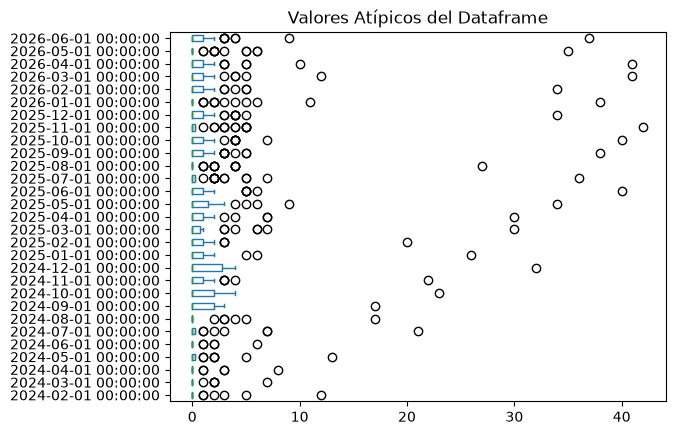

In [12]:
#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize =(15, 8))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del Dataframe")
plt.show() #dibujamos el diagrama

In [15]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas

percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr= percentile75 - percentile25

Limite_Superior_iqr= percentile75 + 1.5*iqr
Limite_Inferior_iqr= percentile25 - 1.5*iqr
print("Limite superior permitido", Limite_Superior_iqr)
print("Limite inferior permitido", Limite_Inferior_iqr)

Limite superior permitido 2024-02-01 00:00:00    0.000
2024-03-01 00:00:00    0.000
2024-04-01 00:00:00    0.000
2024-05-01 00:00:00    0.625
2024-06-01 00:00:00    0.000
2024-07-01 00:00:00    0.625
2024-08-01 00:00:00    0.000
2024-09-01 00:00:00    5.000
2024-10-01 00:00:00    5.000
2024-11-01 00:00:00    2.500
2024-12-01 00:00:00    6.875
2025-01-01 00:00:00    2.500
2025-02-01 00:00:00    2.500
2025-03-01 00:00:00    1.875
2025-04-01 00:00:00    2.500
2025-05-01 00:00:00    3.750
2025-06-01 00:00:00    2.500
2025-07-01 00:00:00    0.625
2025-08-01 00:00:00    0.000
2025-09-01 00:00:00    2.500
2025-10-01 00:00:00    2.500
2025-11-01 00:00:00    0.625
2025-12-01 00:00:00    2.500
2026-01-01 00:00:00    0.000
2026-02-01 00:00:00    2.500
2026-03-01 00:00:00    2.500
2026-04-01 00:00:00    2.500
2026-05-01 00:00:00    0.000
2026-06-01 00:00:00    2.500
dtype: float64
Limite inferior permitido 2024-02-01 00:00:00    0.000
2024-03-01 00:00:00    0.000
2024-04-01 00:00:00    0.000
2024-

In [16]:
#Obtenemos datos limpios del Dataframe
data1_iqr= cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data1_iqr

,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,...,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00,2026-06-01 00:00:00
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,3.0,1.0,...,NaN,NaN,NaN,1.0,NaN,2.0,2.0,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,2.0,1.0,...,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,4.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,2.0,NaN,2.0,1.0,0.0,0.0,0.0
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN
7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,1.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,2.0,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data1_iqr.isnull().sum()
valores_nulos

2024-02-01 00:00:00    31
2024-03-01 00:00:00    31
2024-04-01 00:00:00    31
2024-05-01 00:00:00    31
2024-06-01 00:00:00    31
2024-07-01 00:00:00    31
2024-08-01 00:00:00    31
2024-09-01 00:00:00    24
2024-10-01 00:00:00    21
2024-11-01 00:00:00    23
2024-12-01 00:00:00    19
2025-01-01 00:00:00    20
2025-02-01 00:00:00    23
2025-03-01 00:00:00    29
2025-04-01 00:00:00    26
2025-05-01 00:00:00    26
2025-06-01 00:00:00     6
2025-07-01 00:00:00    13
2025-08-01 00:00:00    12
2025-09-01 00:00:00     9
2025-10-01 00:00:00     8
2025-11-01 00:00:00    13
2025-12-01 00:00:00     8
2026-01-01 00:00:00    12
2026-02-01 00:00:00     6
2026-03-01 00:00:00     6
2026-04-01 00:00:00     7
2026-05-01 00:00:00    12
2026-06-01 00:00:00     8
dtype: int64

In [18]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data2_iqr=data1_iqr.copy()
data2_iqr=data2_iqr.fillna(round(data1_iqr.median(),1))
data2_iqr

,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,2024-11-01 00:00:00,...,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00,2026-06-01 00:00:00
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,1.0,...,0.0,0.0,0.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,1.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,2.0,0.0,2.0,1.0,0.0,0.0,0.0
6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
8,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [20]:
# Unimos el dataframe cuantitativo limpio con el dataframe cualitativo

Datos_limpios = pd.concat([cualitativas, data2_iqr], axis=1)
Datos_limpios.head()

,Vendedor,2024-02-01 00:00:00,2024-03-01 00:00:00,2024-04-01 00:00:00,2024-05-01 00:00:00,2024-06-01 00:00:00,2024-07-01 00:00:00,2024-08-01 00:00:00,2024-09-01 00:00:00,2024-10-01 00:00:00,...,2025-09-01 00:00:00,2025-10-01 00:00:00,2025-11-01 00:00:00,2025-12-01 00:00:00,2026-01-01 00:00:00,2026-02-01 00:00:00,2026-03-01 00:00:00,2026-04-01 00:00:00,2026-05-01 00:00:00,2026-06-01 00:00:00
0,PEDRO GONZALEZ ESPINDOLA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,3.0,...,0.0,0.0,0.0,1.0,0.0,2.0,2.0,0.0,0.0,0.0
1,VICTOR MANUEL SANCHEZ ARRO,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
2,MIGUEL ANGEL SONDEREGGER,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,JOSE ANTONIO LICONA MENDE,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,2.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,JAIME GONZALEZ CORONA,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [21]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=Datos_limpios.isnull().sum()
valores_nulos

Vendedor               0
2024-02-01 00:00:00    0
2024-03-01 00:00:00    0
2024-04-01 00:00:00    0
2024-05-01 00:00:00    0
2024-06-01 00:00:00    0
2024-07-01 00:00:00    0
2024-08-01 00:00:00    0
2024-09-01 00:00:00    0
2024-10-01 00:00:00    0
2024-11-01 00:00:00    0
2024-12-01 00:00:00    0
2025-01-01 00:00:00    0
2025-02-01 00:00:00    0
2025-03-01 00:00:00    0
2025-04-01 00:00:00    0
2025-05-01 00:00:00    0
2025-06-01 00:00:00    0
2025-07-01 00:00:00    0
2025-08-01 00:00:00    0
2025-09-01 00:00:00    0
2025-10-01 00:00:00    0
2025-11-01 00:00:00    0
2025-12-01 00:00:00    0
2026-01-01 00:00:00    0
2026-02-01 00:00:00    0
2026-03-01 00:00:00    0
2026-04-01 00:00:00    0
2026-05-01 00:00:00    0
2026-06-01 00:00:00    0
dtype: int64

In [22]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Ventas_A_Mensual_sin_outliers.csv")